# Example calculation 

In this example we showcase the functionality of adding measurement points to the model. Measurement points can be added to monitor the temperature at position (x,y) in the environment.

Measurement points can be added to a `StaticEnvSoil` only. To add a measurement point, we start by constructing a static environment. See [example_calculation.ipynb](example_calculation.ipynb) for a step by step guide on setting up a model.

In [ ]:
from datetime import datetime

import numpy as np
import pandas as pd

from cable_thermal_model import CableLayer, CablePosition, ModelFactory, StaticEnvSoil
from cable_thermal_model.cable.schemas.circuit_schemas import CircuitInSoilFromCableIdInputSchema

static_env = StaticEnvSoil()

circuit_input_1 = CircuitInSoilFromCableIdInputSchema(
    x=0.0,
    y=-1,
    circuit_name="circuit_1",
    cable_id="GPLK 10/10 kV 3x185 Al",
    cable_source_file_path="../../data/example_cables.csv",
)
static_env.add_circuit_from_cable_id(circuit_input_1)

StaticEnvSoil
	Circuit circuit_1
		Type: SingleCable
		BondingType: no_bonding
		x: 0.0
		y: -1.0

With a static environment set, we can add one or multiple measurement points. The measurement keys can be used to retrieve the temperature profile after running the model.

In [ ]:
measurement_point_key1 = static_env.add_measurement_point(x=0.1, y=-1.0)
measurement_point_key2 = static_env.add_measurement_point(x=0.3, y=-1.0)

Now, a scenario and a model can be set up.

In [ ]:
# In this case we use a scenario that lasts for a week with a step size of 1 hour.
START_DATE = datetime(2026, 1, 1)
DAYS_TO_SIMULATE = 7

scenario = pd.DataFrame(
    index=pd.date_range(start=START_DATE, end=START_DATE + pd.Timedelta(days=DAYS_TO_SIMULATE), freq="1h")
)

# We set the load of the circuit to oscillate between 50 and 350A with a period of 24 hours.
scenario["load_circuit_1"] = 200 + 150 * np.sin(2 * np.pi * scenario.index.hour / 24)
scenario["ambient_temperature"] = 15  # Ambient temperature is assumed to be constant at 15 degrees Celsius.
scenario["soil_thermal_resistivity"] = 0.75  # Soil thermal resistivity is assumed to be constant at 0.75 mK/W.
scenario["soil_thermal_capacity"] = 2e6  # Soil thermal capacity is assumed to be constant at 2e6 J/(m³K).

scenario.head()

,load_circuit_1,ambient_temperature,soil_thermal_resistivity,soil_thermal_capacity
2026-01-01 00:00:00,200.000000,15,0.75,2000000.0
2026-01-01 01:00:00,238.822857,15,0.75,2000000.0
2026-01-01 02:00:00,275.000000,15,0.75,2000000.0
2026-01-01 03:00:00,306.066017,15,0.75,2000000.0
2026-01-01 04:00:00,329.903811,15,0.75,2000000.0


In [ ]:
model = ModelFactory.create_model(static_env=static_env, scenario=scenario)

The model can be executed to compute the temperature profile over time.

The simulation output is stored in `solution`, and the temperature time series are available in `temperature_result`.  
This includes cable temperatures (e.g., conductor and sheath) as well as temperatures at the added measurement points.

In [ ]:
solution = model.run()
temperature_result = solution.result

temperature_result.head()

circuit_1            measurement_point           
                        single                     x=0.300m   x=0.100m
                     Conductor     Sheath         y=-1.000m  y=-1.000m
2026-01-01 00:00:00  15.000000  15.000000         15.000000  15.000000
2026-01-01 01:00:00  24.553775  16.687167         15.002660  15.262748
2026-01-01 02:00:00  31.924032  18.656360         15.013093  15.755784
2026-01-01 03:00:00  38.759849  20.708081         15.036851  16.407640
2026-01-01 04:00:00  45.095192  22.765104         15.078364  17.163937

The temperature profile at a measurement point can be retrieved using the forementioned keys.

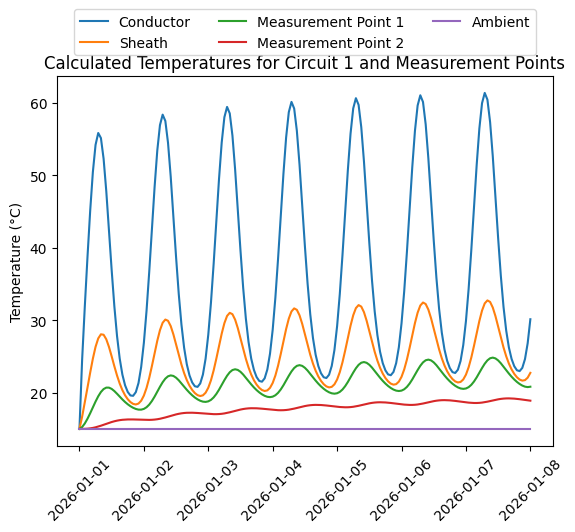

In [ ]:
import matplotlib.pyplot as plt

# Plot the measurement points together with conductor and sheath temperatures.
x = temperature_result.index
series = [
    temperature_result["circuit_1"][CablePosition.Single][CableLayer.Conductor],
    temperature_result["circuit_1"][CablePosition.Single][CableLayer.Sheath],
    temperature_result[measurement_point_key1],
    temperature_result[measurement_point_key2],
    model.scenario["ambient_temperature"],
]
labels = [
    "Conductor",
    "Sheath",
    "Measurement Point 1",
    "Measurement Point 2",
    "Ambient",
]

for y, label in zip(series, labels, strict=True):
    plt.plot(x, y, label=label)

plt.ylabel("Temperature (°C)")
plt.title("Calculated Temperatures for Circuit 1 and Measurement Points")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=3)
plt.xticks(rotation=45)
plt.show()